# Attention maps, samples, and confusion matrix

Loads `checkpoints/best.pt` from a run directory and visualizes predictions. Uses only the checkpoint + `get_dataloaders` (same transforms as training).

Set `OUTPUT_DIR` to the folder that contains `checkpoints/best.pt`.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

from mnist_former.config import TrainConfig
from mnist_former.data import get_dataloaders
from mnist_former.inference import load_checkpoint, predict_with_attention

OUTPUT_DIR = Path("../runs/exp2")
CHECKPOINT = OUTPUT_DIR / "checkpoints" / "best.pt"

CLASS_NAMES = (
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, model_cfg, _, ckpt_epoch = load_checkpoint(CHECKPOINT, device=device)
print(f"Loaded epoch {ckpt_epoch}, d_model={model_cfg.d_model}, n_layers={model_cfg.n_layers}")

tc = TrainConfig(batch_size=64, num_workers=0)
_, _, test_loader = get_dataloaders(tc)

Loaded epoch 14, d_model=32, n_layers=2


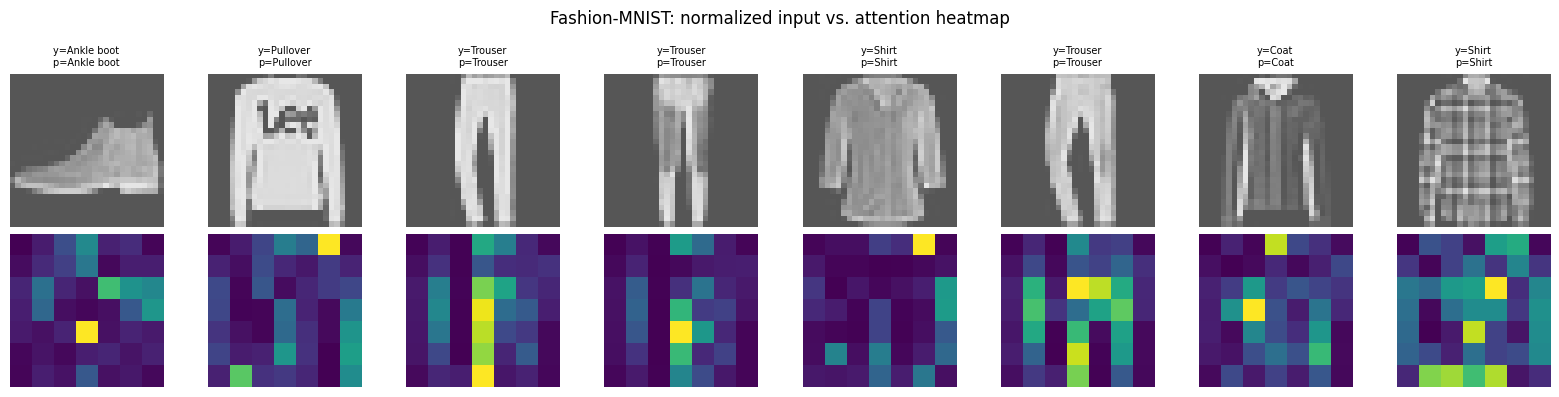

In [2]:
# Sample batch: images + cls->patch attention (layer 0, mean over heads)
x, y = next(iter(test_loader))
x = x.to(device)
y = y.to(device)
n_show = min(8, x.size(0))

logits, attn_list = predict_with_attention(model, x[:n_show])
pred = logits.argmax(dim=-1)

# cls token is index 0; patch tokens 1..num_patches
aw0 = attn_list[0][:n_show]  # (B, H, T, T)
cls_to_patch = aw0.mean(dim=1)[:, 0, 1:]  # (B, num_patches)
gh = int(math.sqrt(model_cfg.num_patches))
gw = gh

fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
for i in range(n_show):
    im = x[i, 0].cpu().numpy()
    axes[0, i].imshow(im, cmap="gray", vmin=-2.5, vmax=2.5)
    axes[0, i].axis("off")
    axes[0, i].set_title(f"y={CLASS_NAMES[y[i]]}\np={CLASS_NAMES[pred[i]]}", fontsize=7)
    hm = cls_to_patch[i].reshape(gh, gw).cpu().numpy()
    axes[1, i].imshow(hm, cmap="viridis")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("input")
axes[1, 0].set_ylabel("cls→patch L0")
plt.suptitle("Fashion-MNIST: normalized input vs. attention heatmap")
plt.tight_layout()
plt.show()

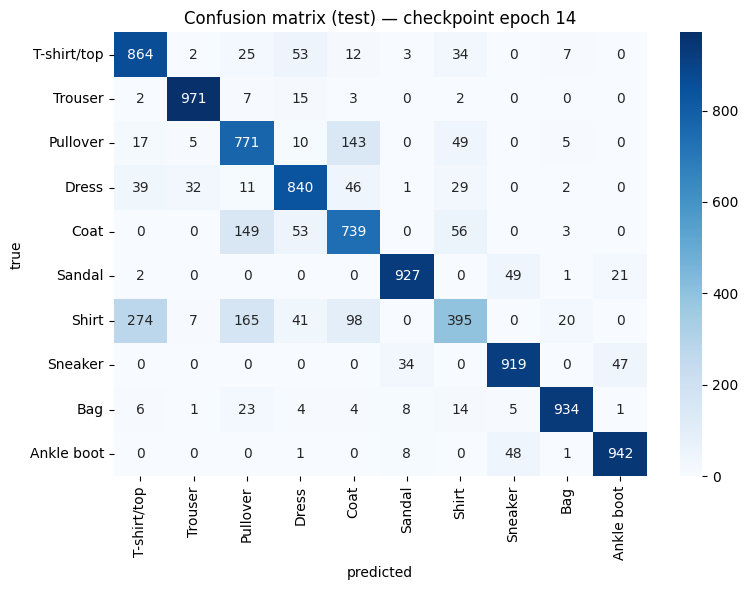

In [2]:
# Confusion matrix on full test set (fast on CPU/GPU)
model.eval()
cm = np.zeros((10, 10), dtype=np.int64)
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pr = model(xb).argmax(dim=-1)
        for t, p in zip(yb.view(-1), pr.view(-1)):
            cm[int(t), int(p)] += 1

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.ylabel("true")
plt.xlabel("predicted")
plt.title(f"Confusion matrix (test) — checkpoint epoch {ckpt_epoch}")
plt.tight_layout()
plt.show()